In [57]:
# FASE 1: IMPORTAÇÃO DE FERRAMENTAS
# Pense nisso como pegar sua caixa de ferramentas antes de consertar um carro.
import pandas as pd             # Para ler e manipular tabelas de dados (Excel do Python)
import numpy as np              # Para cálculos matemáticos pesados
from tensorflow.keras.models import Sequential # O esqueleto da nossa rede neural
from tensorflow.keras.layers import Dense, Dropout # Os 'orgãos' da rede (neurônios)
from sklearn.model_selection import train_test_split # Para dividir a prova do estudo
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Para traduzir dados para 'idioma de máquina'
import tensorflow as tf

In [58]:
# FASE 2: PREPARAÇÃO DOS DADOS (O COMBUSTÍVEL)
# ==========================================
# Uma rede neural é tão boa quanto os dados que ela consome.

# 1. Carregamento
# Buscamos a tabela de flores na internet.
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
dataframe = pd.read_csv(url)

# 2. Separação (Inputs vs Output)
# A rede precisa saber: "O que eu vejo?" (X) e "O que é?" (y)
# X = Medidas da pétala e sépala (4 colunas)
# y = Nome da espécie (1 coluna)
X_features = dataframe.iloc[:, -5:-1].values
y_target = dataframe.iloc[:, -1].values.reshape(-1, 1)

# 3. Tradução do Alvo (One-Hot Encoding)
# O computador não lê "Setosa". Ele lê números.
# Transformamos "Setosa" em [1, 0, 0], "Versicolor" em [0, 1, 0], etc.
codificador = OneHotEncoder(sparse_output=False)
y_codificado = codificador.fit_transform(y_target)

# 4. Normalização (Standard Scaler)
# Importante para o Backpropagation! Coloca todos os números na mesma escala.
# Se uma medida é 1000 e outra é 0.1, a rede fica confusa. Aqui, tudo fica equilibrado.
escalonador = StandardScaler()
X_escalonado = escalonador.fit_transform(X_features)

# 5. Divisão Treino vs Teste
# Estudamos com 80% das provas antigas e deixamos 20% guardadas para o teste final.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_escalonado, y_codificado, test_size=0.3, random_state=42
)

In [66]:
# FASE 3: CONSTRUINDO O CÉREBRO DIGITAL
# ==========================================
tf.keras.backend.clear_session()

modelo = Sequential() # Iniciamos uma rede sequencial (camada após camada)

# CAMADA 1 (Entrada + Oculta):
# - Dense(16): Criamos 16 neurônios artificiais.
# - input_dim=4: Eles têm 4 "olhos" para ver as 4 medidas da flor.
# - activation='relu': A 'ReLU' decide se o neurônio dispara ou não. Se o valor for negativo, zera.
modelo.add(Dense(16, input_dim=4, activation='relu'))

# CAMADA DE DROPOUT (Prevenção de 'Decoreba'):
# - Desliga 20% dos neurônios aleatoriamente a cada rodada.
# - Isso obriga a rede a aprender o conceito, não decorar os exemplos.
modelo.add(Dropout(0.2))

# CAMADA 2 (Oculta):
# - Mais 8 neurônios para processar informações mais abstratas.
modelo.add(Dense(8, activation='relu'))

# CAMADA DE SAÍDA (A Decisão):
# - 3 neurônios: Um para cada tipo de flor possível.
# - activation='softmax': Transforma números em % de probabilidade (ex: 90% ser Setosa).
modelo.add(Dense(3, activation='softmax'))

In [60]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
# FASE 4: O MOTOR DE APRENDIZADO
# ==========================================
modelo.compile(
    optimizer='adam',                   # O 'Adam' é o gerente que ajusta os erros (Backpropagation).
    loss='categorical_crossentropy',    # A 'Loss' calcula quão errada foi a resposta.
    metrics=['accuracy']                # Queremos maximizar a Acurácia (taxa de acerto).
)

In [68]:
# FASE 5: AULA (TREINAMENTO)
# ==========================================
print("--- INICIANDO TREINAMENTO ---")

historico = modelo.fit(
    X_treino, y_treino,
    epochs=65,           # Vamos passar a matéria completa 100 vezes.
    batch_size=8,         # O professor corrige os exercícios de 8 em 8 alunos.
    validation_data=(X_teste, y_teste), # O teste simulado a cada época.
    verbose=1
)

print("\n--- TREINAMENTO CONCLUÍDO ---")
print("O modelo agora sabe diferenciar flores com base em medidas matemáticas!")

--- INICIANDO TREINAMENTO ---
Epoch 1/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.1747 - loss: 1.1326 - val_accuracy: 0.4000 - val_loss: 1.0599
Epoch 2/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3549 - loss: 1.0642 - val_accuracy: 0.5556 - val_loss: 1.0006
Epoch 3/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5650 - loss: 1.0012 - val_accuracy: 0.6444 - val_loss: 0.9455
Epoch 4/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6270 - loss: 0.9667 - val_accuracy: 0.6667 - val_loss: 0.8920
Epoch 5/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5551 - loss: 0.9575 - val_accuracy: 0.7333 - val_loss: 0.8461
Epoch 6/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6287 - loss: 0.9113 - val_accuracy: 0.7556 - val_loss: 0.7929
Epoch 7/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7412 - loss: 0.8254 - val_accuracy: 0.7556 - val_loss: 0.7422
Epoch 8/65
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7375 - loss: 0.8244 

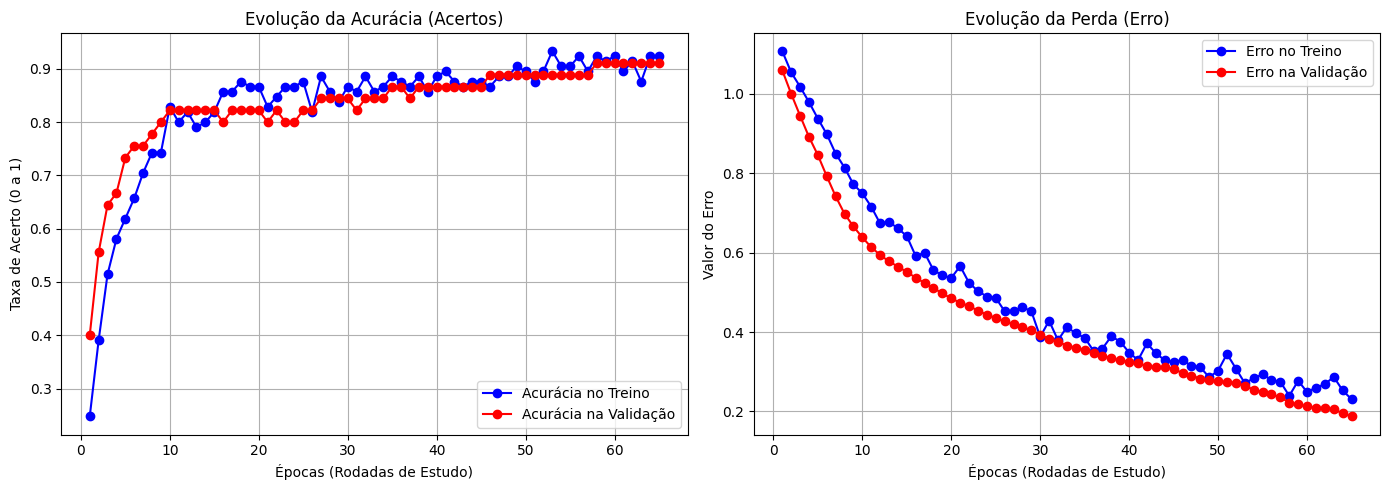

In [69]:
# ==========================================
# FASE 6: VISUALIZANDO O APRENDIZADO
# ==========================================
import matplotlib.pyplot as plt

# Pegamos os dados guardados no histórico
acc = historico.history['accuracy']
val_acc = historico.history['val_accuracy']
loss = historico.history['loss']
val_loss = historico.history['val_loss']
epochs = range(1, len(acc) + 1)

# Criamos uma figura com 2 gráficos lado a lado
plt.figure(figsize=(14, 5))

# GRÁFICO 1: ACURÁCIA (Precisão)
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Acurácia no Treino')      # 'bo-' = bolinha azul ligada
plt.plot(epochs, val_acc, 'ro-', label='Acurácia na Validação') # 'ro-' = bolinha vermelha ligada
plt.title('Evolução da Acurácia (Acertos)')
plt.xlabel('Épocas (Rodadas de Estudo)')
plt.ylabel('Taxa de Acerto (0 a 1)')
plt.legend()
plt.grid(True)

# GRÁFICO 2: PERDA (Erro)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Erro no Treino')
plt.plot(epochs, val_loss, 'ro-', label='Erro na Validação')
plt.title('Evolução da Perda (Erro)')
plt.xlabel('Épocas (Rodadas de Estudo)')
plt.ylabel('Valor do Erro')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
--- RELATÓRIO DE MÉTRICAS ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        19
  Versicolor       1.00      0.85      0.92        13
   Virginica       0.87      1.00      0.93        13

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



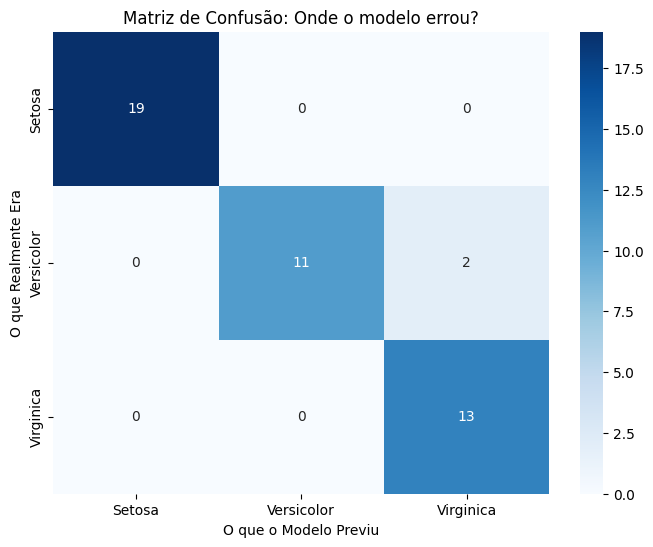

In [40]:
# ==========================================
# FASE 7: BOLETIM DETALHADO (AVALIAÇÃO)
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Fazendo a prova final (Previsões)
# A rede nos dá probabilidades (ex: 0.1, 0.8, 0.1). Precisamos escolher a maior.
y_probabilidades = modelo.predict(X_teste)
y_predicoes = np.argmax(y_probabilidades, axis=1)

# Como nossos dados de teste (y_teste) estão codificados (One-Hot),
# também precisamos converter eles de volta para números simples (0, 1, 2) para comparar.
y_reais = np.argmax(y_teste, axis=1)

# Nomes das classes para facilitar a leitura
nomes_flores = ['Setosa', 'Versicolor', 'Virginica']

# 2. Relatório de Classificação
print("--- RELATÓRIO DE MÉTRICAS ---")
print(classification_report(y_reais, y_predicoes, target_names=nomes_flores))

# 3. Matriz de Confusão Visual
# Mostra: "Era Setosa, mas o modelo disse Virginica"
plt.figure(figsize=(8, 6))
matriz = confusion_matrix(y_reais, y_predicoes)

sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_flores, yticklabels=nomes_flores)
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Era')
plt.title('Matriz de Confusão: Onde o modelo errou?')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Calculando a importância das características... (pode demorar um pouquinho)


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━

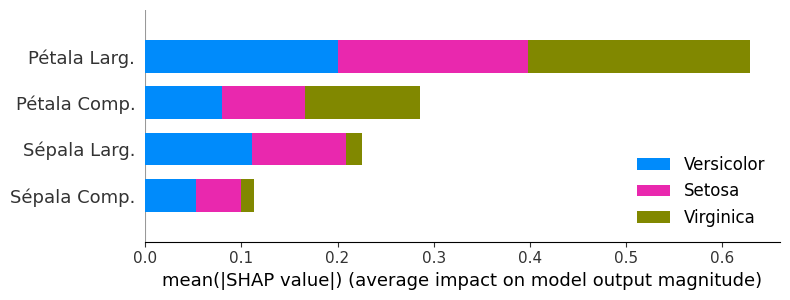

In [41]:
# ==========================================
# FASE BÔNUS: EXPLICANDO O PORQUÊ (SHAP)
# ==========================================
# "Por que o modelo decidiu que é uma Setosa e não uma Virginica?"
# O SHAP (SHapley Additive exPlanations) responde isso mostrando
# o impacto de cada medida na decisão final.

# 1. Instalação da ferramenta (caso não tenha)
!pip install shap -q
import shap

# 2. Criando o "Detetive" (Explainer)
# O KernelExplainer testa o modelo com diferentes combinações de entradas
# para descobrir quais são as mais importantes.
# Usamos uma amostra do treino (X_treino) como base de comparação.
# (Usamos apenas 50 exemplos para ser rápido na aula)
explainer = shap.KernelExplainer(modelo.predict, X_treino[:50])

# 3. Investigando as previsões (Calculando valores SHAP)
# Vamos analisar 20 flores do teste para ver o que pesou na decisão.
print("\nCalculando a importância das características... (pode demorar um pouquinho)")
shap_values = explainer.shap_values(X_teste[:20])

# 4. Visualizando o Resumo
# Este gráfico é ideal para apresentações. Ele resume a "força" de cada característica.
nomes_features = ['Sépala Comp.', 'Sépala Larg.', 'Pétala Comp.', 'Pétala Larg.']
nomes_classes = ['Setosa', 'Versicolor', 'Virginica'] # Nomes para a legenda

print("--- RANKING DE IMPORTÂNCIA (EM BARRAS) ---")
print("Interpretação: As barras maiores são as características que o modelo mais considera.")

# O parâmetro plot_type="bar" cria o gráfico simplificado
# Adicionamos class_names=nomes_classes para a legenda ficar legível
shap.summary_plot(shap_values, X_teste[:20], feature_names=nomes_features, class_names=nomes_classes, plot_type="bar")